In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

# 1. Chargement des données (Chemin pour dossier /notebooks)
path = '../data/insurance.csv'

if os.path.exists(path):

    dtype_dict = {'age': 'int8', 'sex': 'category', 'bmi': 'float16', 'children': 'int8', 'smoker': 'category', 'region': 'category', 'charges': 'float32'}

    df = pd.read_csv(path, low_memory=True, dtype=dtype_dict)
    df["smoker"] = df["smoker"].map({"yes": 1, "no": 0}).astype("bool")
    df["sex"] = df["sex"].map({"female": 1, "male": 0}).astype("bool")
    df.info()
    print(" Les données sont prêtes pour l'analyse de la Semaine 1.")
    print(f"Dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print(f" Erreur : Je ne trouve pas le fichier au chemin : {path}")
    print("Vérifie bien que ton notebook est dans  le dossier 'notebooks'.")


df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int8    
 1   sex       1338 non-null   bool    
 2   bmi       1338 non-null   float16 
 3   children  1338 non-null   int8    
 4   smoker    1338 non-null   bool    
 5   region    1338 non-null   category
 6   charges   1338 non-null   float32 
dtypes: bool(2), category(1), float16(1), float32(1), int8(2)
memory usage: 14.7 KB
 Les données sont prêtes pour l'analyse de la Semaine 1.
Dataset : 1338 lignes et 7 colonnes.


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
# 3 Informations sur le DataFrame
# contrôle des doublons
df.duplicated().sum()

# Visualiser le doublon
df[df.duplicated()]

# Vérifier doublons sur les colonnes clés
df.duplicated(subset=["age","sex","bmi","children","smoker","region"]).sum()

# Voir toutes les lignes concernées
df[df.duplicated(keep=False)]

# Suppression des doublons
df = df.drop_duplicates()

# Vérification après suppression
df.duplicated().sum()





np.int64(0)

In [9]:
# Statistiques de base : mean, median, std, min, max, quartiles
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.656250,1.095737,13279.122070
std,14.044333,6.101562,1.205571,12110.359375
min,18.000000,15.960938,0.000000,1121.873901
25%,27.000000,26.296875,0.000000,4746.344238
50%,39.000000,30.406250,1.000000,9386.161133
75%,51.000000,34.687500,2.000000,16657.716797
max,64.000000,53.125000,5.000000,63770.429688


In [10]:
# Nombre de valeurs uniques par colonne
df.nunique()



age           47
sex            2
bmi          486
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [11]:


region_counts = (
    df.groupby("region")
      .size()
      .reset_index(name="count")
)
print(region_counts)

region_charge_sum = (
    df.groupby("region")["charges"]
        .sum()
        .reset_index(name="total_charges")
)
print(region_charge_sum)

region_charge_mean = (
    df.groupby("region")["charges"]
    .mean()
    .reset_index(name="mean_charges")
)
print(region_charge_mean)

px.bar(
    region_counts,
    x="region",
    y="count",
    title="Number of insured persons per region "
).show()

px.bar(
    region_charge_sum,
    x="region",
    y="total_charges",
    title="total charges per region "
).show()

px.bar(
    region_charge_mean,
    x="region",
    y="mean_charges",
    title="mean of charges per region "
).show()








      region  count
0  northeast    324
1  northwest    324
2  southeast    364
3  southwest    325
      region  total_charges
0  northeast     4343668.50
1  northwest     4034072.50
2  southeast     5363690.00
3  southwest     4012754.75
      region  mean_charges
0  northeast  13406.383789
1  northwest  12450.840820
2  southeast  14735.412109
3  southwest  12346.937500


C:\Users\Admin\AppData\Local\Temp\ipykernel_15860\1955134148.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")
C:\Users\Admin\AppData\Local\Temp\ipykernel_15860\1955134148.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")["charges"]
C:\Users\Admin\AppData\Local\Temp\ipykernel_15860\1955134148.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("region")["charges"]

BMI Analyse

In [12]:
df["bmi"] = df["bmi"].astype("float64")

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

bmi_counts = (
    df.groupby("bmi_category", observed=True)
      .size()
      .reset_index(name="count")
)
print(bmi_counts)

bmi_charge_sum = (
    df.groupby("bmi_category", observed=True)["charges"]
      .sum()
      .reset_index(name="total_charges")
)
print(bmi_charge_sum)

bmi_charge_mean = (
    df.groupby("bmi_category", observed=True)["charges"]
      .mean()
      .reset_index(name="mean_charges")
)
print(bmi_charge_mean)


px.bar(
    bmi_counts,
    x="bmi_category",
    y="count",
    title="Number of insured persons per BMI category"
).show()

px.bar(
    bmi_charge_sum,
    x="bmi_category",
    y="total_charges",
    title="Total charges per BMI category"
).show()

px.bar(
    bmi_charge_mean,
    x="bmi_category",
    y="mean_charges",
    title="Mean charges per BMI category"
).show()

  bmi_category  count
0  Underweight     21
1       Normal    226
2   Overweight    386
3        Obese    704
  bmi_category  total_charges
0  Underweight   1.818100e+05
1       Normal   2.358410e+06
2   Overweight   4.245152e+06
3        Obese   1.096881e+07
  bmi_category  mean_charges
0  Underweight   8657.620117
1       Normal  10435.440430
2   Overweight  10997.804688
3        Obese  15580.700195


In [13]:
bmi_mean = df["bmi"].mean()
bmi_median = df["bmi"].median()
bmi_std = df["bmi"].std()

print("Moyenne BMI :", bmi_mean)
print("Médiane BMI :", bmi_median)
print("Écart-type BMI :", bmi_std)

Moyenne BMI : 30.663466482797308
Médiane BMI : 30.40625
Écart-type BMI : 6.100637508980295


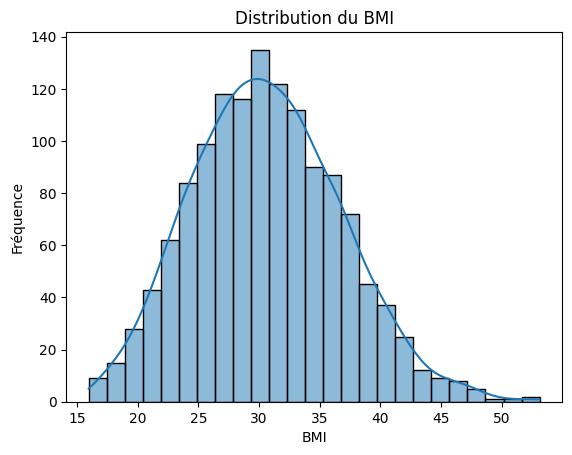

In [14]:
# BMI distribution en valeur absolue

sns.histplot(df["bmi"], kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Fréquence")
plt.show()

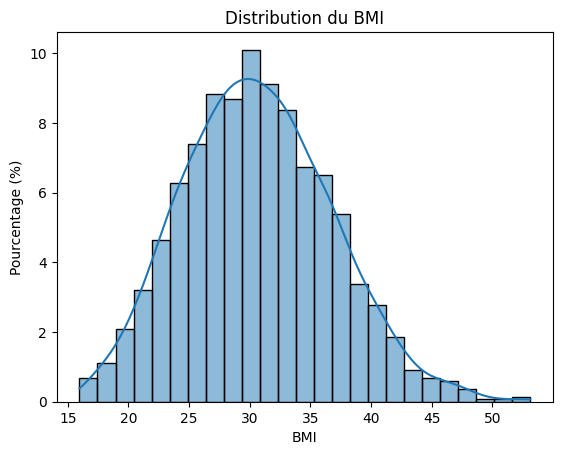

In [15]:
# distribution des BMI en %

sns.histplot(df["bmi"], stat="percent", kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Pourcentage (%)")
plt.show()

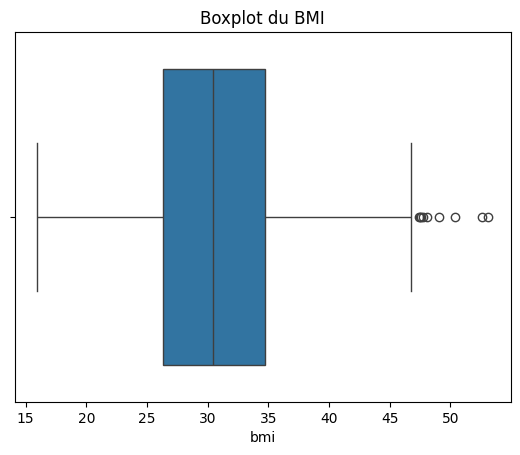

In [16]:
sns.boxplot(x=df["bmi"])
plt.title("Boxplot du BMI")
plt.show()


Smokers Analyse

In [17]:
df["smoker_label"] = df["smoker"].map({True: "Smoker", False: "No-smoker"})

smoker_counts = (
    df.groupby("smoker_label", observed=True)
      .size()
      .reset_index(name="count")
)
print(smoker_counts)

smoker_charge_sum = (
    df.groupby("smoker_label", observed=True)["charges"]
      .sum()
      .reset_index(name="total_charges")
)
print(smoker_charge_sum)

smoker_charge_mean = (
    df.groupby("smoker_label", observed=True)["charges"]
      .mean()
      .reset_index(name="mean_charges")
)
print(smoker_charge_mean)

px.bar(
    smoker_counts,
    x="smoker_label",
    y="count",
    title="Number of insured persons by smoking status"
).show()

px.bar(
    smoker_charge_sum,
    x="smoker_label",
    y="total_charges",
    title="Total charges by smoking status"
).show()

px.bar(
    smoker_charge_mean,
    x="smoker_label",
    y="mean_charges",
    title="Mean charges by smoking status"
).show()

  smoker_label  count
0    No-smoker   1063
1       Smoker    274
  smoker_label  total_charges
0    No-smoker      8972422.0
1       Smoker      8781764.0
  smoker_label  mean_charges
0    No-smoker   8440.660156
1       Smoker  32050.234375


In [38]:
# en %
df["smoker"].value_counts(normalize=True) * 100

smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64

In [19]:
# Mediane et mean des charges pr fumeurs ou non

df.groupby("smoker")["charges"].agg(["count", "mean", "median"])

,count,mean,median
smoker,,,
False,1063,8440.660156,7345.726562
True,274,32050.234375,34456.347656


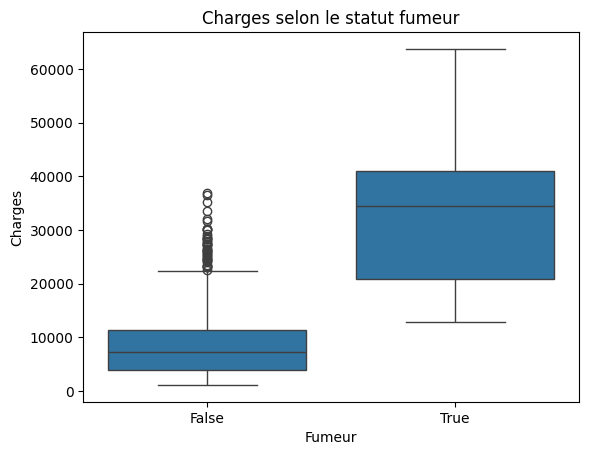

In [20]:
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges selon le statut fumeur")
plt.xlabel("Fumeur")
plt.ylabel("Charges")
plt.show()

Fumeurs et Bmi

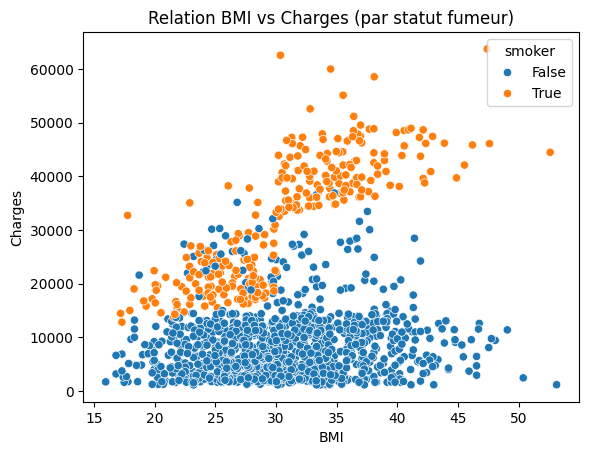

In [21]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("Relation BMI vs Charges (par statut fumeur)")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

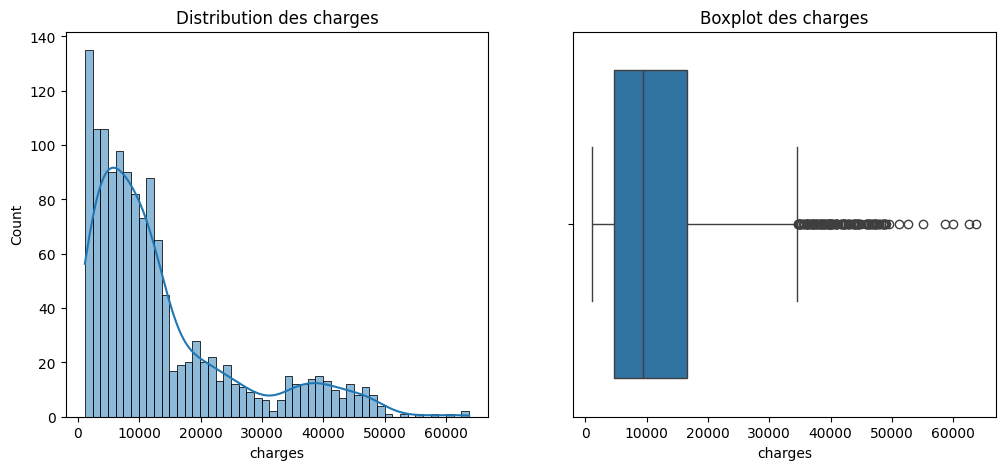

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")

plt.subplot(1,2,2)
sns.boxplot(x=df['charges'])
plt.title("Boxplot des charges")

plt.show()


In [23]:
quantiles = df['charges'].quantile([0.90, 0.95, 0.99])
print(quantiles)

total_charges = df['charges'].sum()

for q in [0.95, 0.99]:
    threshold = df['charges'].quantile(q)
    part = df[df['charges'] >= threshold]['charges'].sum() / total_charges
    print(f"Part des charges au-dessus du quantile {q*100:.0f}% : {part:.2%}")


0.90    34832.738281
0.95    41210.046875
0.99    48537.796875
Name: charges, dtype: float32
Part des charges au-dessus du quantile 95% : 17.58%
Part des charges au-dessus du quantile 99% : 4.20%


5% des assurer 17.58% des charges totales

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Optionnel : style seaborn
sns.set(style="whitegrid")


In [25]:
# Chemin vers ton dataset
path = '../data/insurance.csv'

dtype_dict = {
    'age': 'int32', 'sex': 'category', 'bmi': 'float32',
    'children': 'int32', 'smoker': 'category', 'region': 'object',
    'charges': 'float64'
}

df = pd.read_csv(path, dtype=dtype_dict)


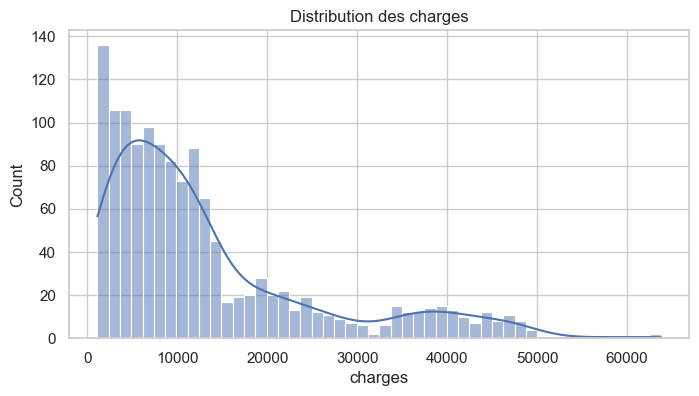

In [26]:
# Charges
plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")
plt.show()

#1️Histogramme des charges
# Montre la distribution des charges d’assurance.
# Observation : majorité des charges autour de 10 000$, quelques outliers très élevés (>50 000$), distribution asymétrique à droite.
# Conclusion : certaines valeurs extrêmes pourraient influencer un modèle, envisager une transformation log.

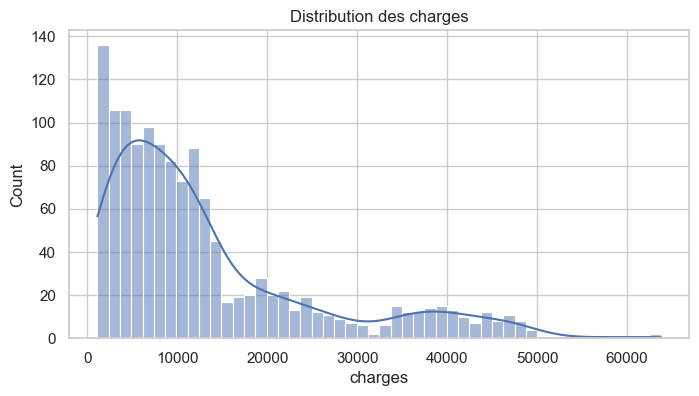

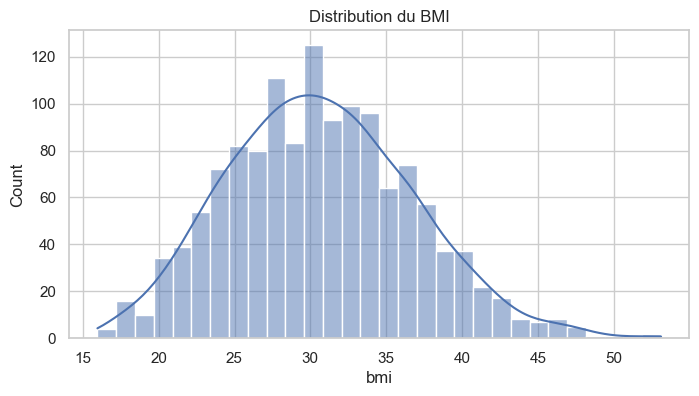

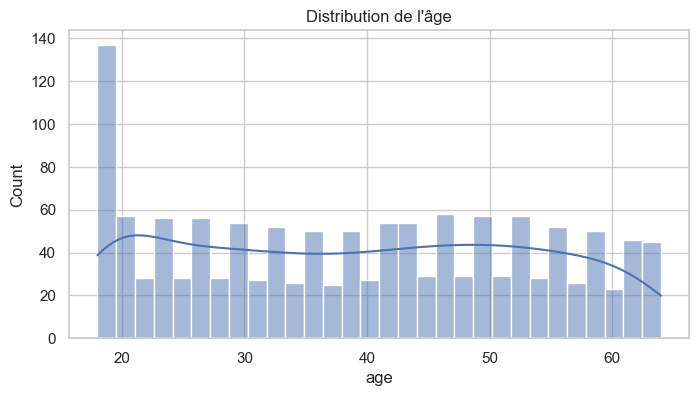

In [27]:
# 1️ Histogramme des charges
# Montre la distribution des charges d’assurance.
# Observation : majorité des charges autour de 10 000$, quelques outliers très élevés (>50 000$), distribution asymétrique à droite.
# Conclusion : certaines valeurs extrêmes pourraient influencer un modèle, envisager une transformation log.
plt.figure(figsize=(8,4))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Distribution des charges")
plt.show()


# 2️ Histogramme du BMI
# Montre la distribution de l’indice de masse corporelle (BMI).
# Observation : la plupart des assurés ont un BMI entre 20 et 35, quelques valeurs extrêmes plausibles.
# Conclusion : valeurs cohérentes, pas besoin de nettoyage, mais noter quelques outliers.
plt.figure(figsize=(8,4))
sns.histplot(df['bmi'], bins=30, kde=True)
plt.title("Distribution du BMI")
plt.show()


# 3️ Histogramme de l’âge
# Montre la répartition des âges.
# Observation : âge entre 18 et 64 ans, distribution assez normale.
# Conclusion : variable propre et cohérente, pas de valeurs aberrantes.
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.show()




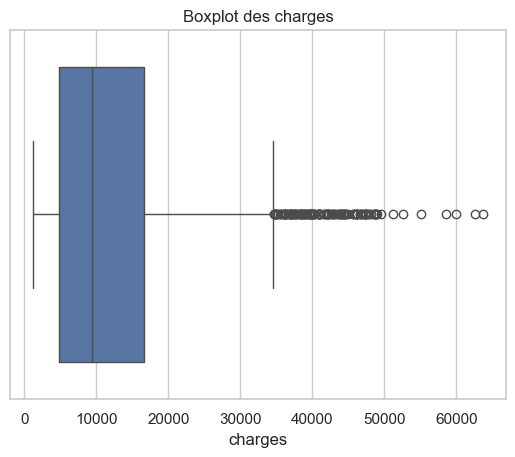

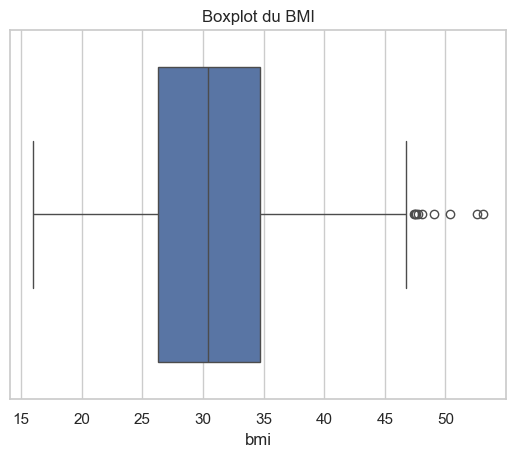

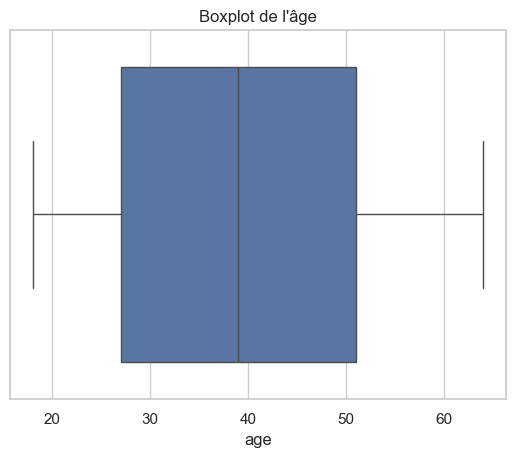

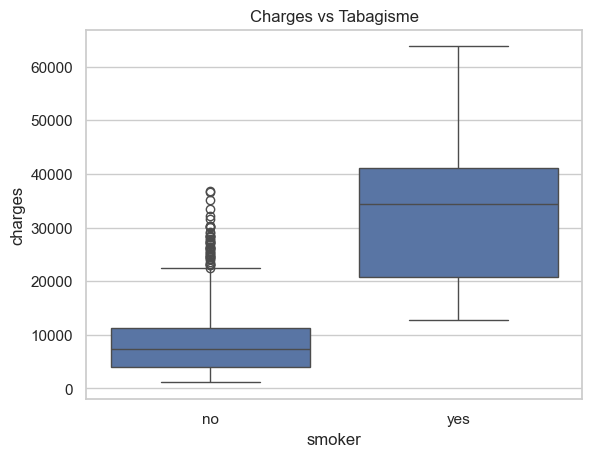

In [28]:
# 1️Boxplot des charges
# Visualise la médiane, les quartiles et les outliers pour les charges.
# Observation : la majorité des charges est concentrée autour de 10 000$, mais il existe plusieurs outliers très élevés (>50 000$).
# Conclusion : ces valeurs extrêmes pourraient influencer un modèle linéaire. On pourrait envisager une transformation log pour réduire l'effet des outliers.

sns.boxplot(x=df['charges'])
plt.title("Boxplot des charges")
plt.show()


#2️ Boxplot du BMI
# Montre la distribution du BMI avec médiane, quartiles et outliers.
# Observation : la plupart des individus ont un BMI entre 20 et 35, quelques valeurs extrêmes au-delà de 50.
# Conclusion : les valeurs sont plausibles, mais les outliers doivent être notés pour l'analyse et éventuellement le scaling.

sns.boxplot(x=df['bmi'])
plt.title("Boxplot du BMI")
plt.show()


# 3️ Boxplot de l'âge
# Visualise la répartition de l'âge.
# Observation : âge compris entre 18 et 64 ans, distribution plutôt normale, peu d’outliers.
# Conclusion : variable propre et cohérente, pas besoin de nettoyage.

sns.boxplot(x=df['age'])
plt.title("Boxplot de l'âge")
plt.show()


# 4️ Boxplot Charges vs Tabagisme
# Compare les charges entre fumeurs et non-fumeurs.
# Observation : les fumeurs ont des charges beaucoup plus élevées que les non-fumeurs, avec des outliers encore plus extrêmes.
# Conclusion : tabagisme est un facteur clé pour expliquer les charges. Cette variable doit absolument être incluse dans le modèle.
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Tabagisme")
plt.show()



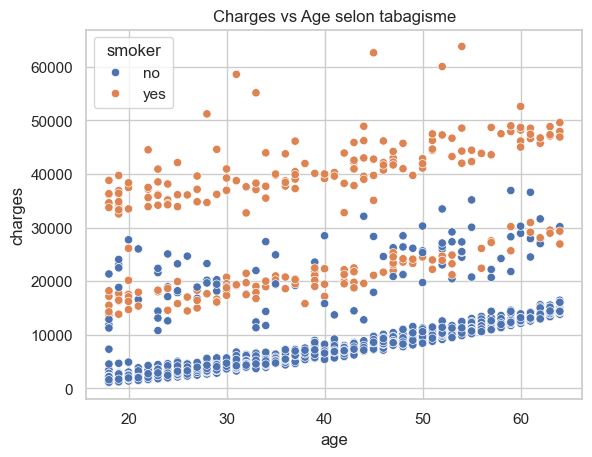

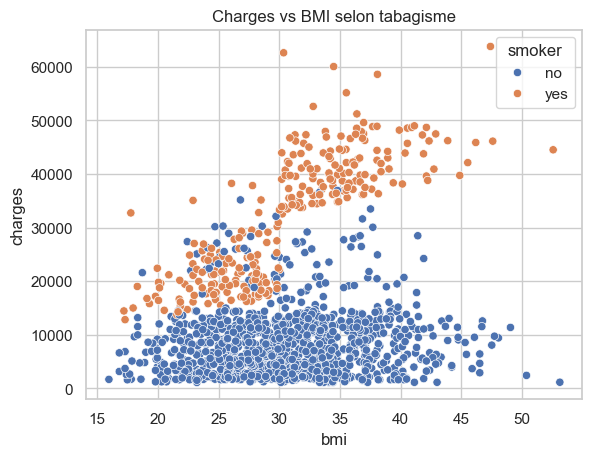

In [29]:
# 1️Scatterplot Charges vs Age
# Visualise la relation entre l'âge et les charges, en différenciant fumeurs et non-fumeurs.
# Observation : 
# - Pour les non-fumeurs, les charges restent relativement faibles et ne varient pas beaucoup avec l'âge.
# - Pour les fumeurs, les charges augmentent avec l'âge, et il existe des outliers très élevés.
# Conclusion : l'effet de l'âge sur les charges dépend fortement du tabagisme. 
# Cette interaction age × smoker sera importante à prendre en compte dans le modèle.

sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Charges vs Age selon tabagisme")
plt.show()


#2️ Scatterplot Charges vs BMI
# Visualise la relation entre le BMI et les charges, en différenciant fumeurs et non-fumeurs.
# Observation : 
# - Pour les non-fumeurs, charges modérées, légère augmentation avec BMI.
# - Pour les fumeurs, charges augmentent plus fortement avec BMI, avec plusieurs outliers extrêmes.
# Conclusion : le BMI impacte surtout les fumeurs. L'interaction BMI × smoker est un facteur important pour prédire les charges.

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("Charges vs BMI selon tabagisme")
plt.show()



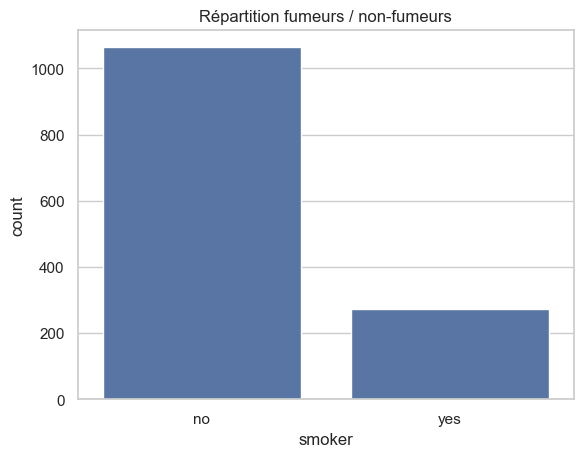

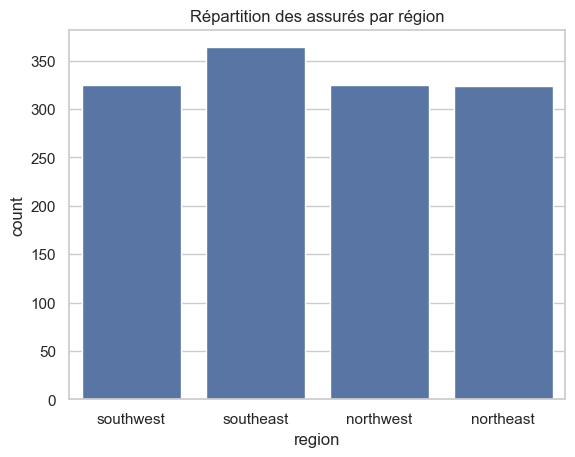

In [30]:
# 1️ Répartition fumeurs / non-fumeurs
# Visualise le nombre d'individus fumeurs et non-fumeurs.
# Observation : environ 80% des assurés sont non-fumeurs et 20% sont fumeurs.
# Conclusion : la variable "smoker" est déséquilibrée mais très importante pour expliquer les charges. 
# Elle devra être incluse dans le modèle et pourrait influencer la prédiction fortement.

sns.countplot(x='smoker', data=df)
plt.title("Répartition fumeurs / non-fumeurs")
plt.show()


# 2️ Répartition des assurés par région
# Visualise le nombre d'individus dans chaque région.
# Observation : les quatre régions (northeast, northwest, southeast, southwest) sont relativement équilibrées (~320–360 assurés chacune).
# Conclusion : peu de biais lié à la région. Cette variable peut être utile pour des analyses groupées ou comme variable catégorielle dans le modèle.

sns.countplot(x='region', data=df)
plt.title("Répartition des assurés par région")
plt.show()



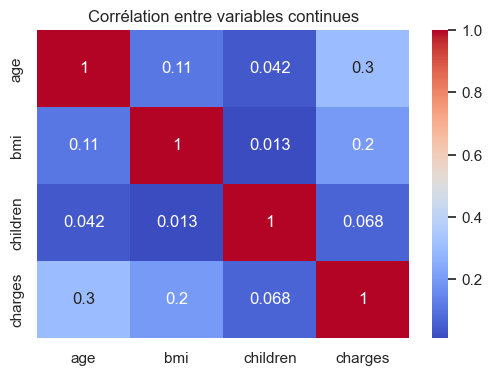

In [31]:
# Heatmap : Corrélation entre variables continues
# Visualise les corrélations entre âge, BMI, nombre d'enfants et charges.
# Observation :
# - Charges corrèlent positivement avec l'âge (corr ~0.3) et le BMI (corr ~0.2-0.3).
# - Très faible corrélation entre charges et le nombre d'enfants (corr ~0.1), donc peu d'impact.
# - Corrélations entre les autres variables continues restent faibles/modérées.
# Conclusion :
# - Les variables continues les plus importantes pour expliquer les charges sont l'âge et le BMI.
# - Children a peu d'effet et pourrait être moins influente dans le modèle.
# - Cette visualisation aide à comprendre quelles variables pourraient être prioritaires pour la modélisation.
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','bmi','children','charges']].corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre variables continues")
plt.show()



In [32]:

# SYNTHESE FINALE – ANALYSE EXPLORATOIRE (SEMAINE 1)

# Qualité et structure des données
# - Le jeu de données est globalement propre.
# - Aucune valeur manquante critique n’a été détectée.
# - Un nombre très limité de doublons a été identifié et traité.
# - Les types de variables sont cohérents :
#   numériques (age, bmi, children, charges) et catégorielles (sex, smoker, region).

# Analyse des distributions
# - Charges :
#   Distribution fortement asymétrique à droite avec plusieurs valeurs extrêmes (>50 000$).
#   Ces outliers peuvent fortement influencer un modèle linéaire.
#   Une transformation logarithmique des charges pourra être envisagée par la suite.
#
# - BMI :
#   La majorité des valeurs est comprise entre 20 et 35.
#   Quelques valeurs extrêmes existent mais restent plausibles.
#   Variable exploitable telle quelle, tout en gardant les outliers en mémoire.
#
# - Age :
#   Distribution cohérente entre 18 et 64 ans.
#   Pas de valeurs aberrantes significatives.
#   Variable stable et bien adaptée à la modélisation.

# Relations entre variables
# - Le tabagisme est le facteur le plus discriminant :
#   Les fumeurs ont des charges nettement plus élevées que les non-fumeurs.
#
# - L'âge et le BMI ont un impact positif sur les charges,
#   impact beaucoup plus marqué chez les fumeurs.
#
# - Le nombre d’enfants a une corrélation faible avec les charges.
#
# - Les régions sont relativement équilibrées et n’expliquent pas fortement les charges.

# Enseignements pour la suite du projet
# - Variables clés pour la modélisation :
#   smoker, age, bmi.
# - Présence d’outliers et asymétrie des charges :
#   nécessité d’un scaling et potentiellement d’une transformation log.
# - Ces observations justifient la mise en place d’un pipeline de préparation
#   avant la modélisation (Semaine 2 : baseline et évaluation).


In [33]:
import pandas as pd

df = pd.read_csv("../data/insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
from ydata_profiling import ProfileReport

# Création du rapport
profile = ProfileReport(
    df,
    title="Insurance Dataset – EDA Report",
    explorative=True
)

# Affichage du rapport
profile



ModuleNotFoundError: No module named 'ydata_profiling'